In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import py3Dmol
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

from mdm2_breaker import (
    GraphSiameseNetwork_v5,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer,
    SmallMoleculeFeaturizer_v5,
)

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(
    ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

In [3]:
EPOCHS = 100
LR = 1e-4

## Utility Functions

In [4]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

In [5]:
def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)

    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {
        0: "C",
        1: "N",
        2: "O",
        3: "F",
        4: "S",
        5: "Cl",
        6: "Br",
        7: "I",
        8: "?",
    }

    # Create labels and colors for the plot
    labels = {}
    node_colors = []

    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()

        element = atom_map.get(feat_idx, "?")
        labels[node_idx] = f"{node_idx}:{element}"  # Format: "Index:Element"

        # Color logic (CPK-ish coloring)
        if element == "C":
            node_colors.append("gray")
        elif element == "N":
            node_colors.append("blue")
        elif element == "O":
            node_colors.append("red")
        elif element == "S":
            node_colors.append("yellow")
        elif element == "Cl":
            node_colors.append("lightgreen")
        else:
            node_colors.append("orange")

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)  # Force-directed layout

    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        node_size=800,
        font_color="white",
        font_weight="bold",
        edge_color="black",
    )

    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

In [6]:
class SarcomaScoutSystem(pl.LightningModule):
    def __init__(
        self, model: torch.nn.Module, protein_graph: Data, lr: float = 0.00005
    ):
        """
        Args:
            model (torch.nn.Module): An instantiated Siamese Network (v1, v2, or v3).
            protein_graph (Data): The static graph of the MDM2 pocket.
            lr (float): Learning rate.
        """
        super().__init__()
        # We ignore 'model' and 'protein_graph' in hparams to avoid pickling large objects
        # into the checkpoint header unnecessarily.
        self.save_hyperparameters(ignore=["model", "protein_graph"])

        # 1. Dependency Injection: We store whatever model you passed in.
        self.model = model

        self.lr = lr

        # 2. Store the Protein Graph as a "Buffer"
        # This keeps the static graph on the correct GPU without being a trainable parameter.
        self.register_buffer("protein_x", protein_graph.x)
        self.register_buffer("protein_edge_index", protein_graph.edge_index)

        # Create a dummy batch vector [0, 0, 0...] for the single protein
        batch_vec = torch.zeros(protein_graph.x.size(0), dtype=torch.long)
        self.register_buffer("protein_batch", batch_vec)

    def get_protein_graph(self):
        """Reconstructs the Data object from the GPU buffers."""
        return Data(
            x=self.protein_x,
            edge_index=self.protein_edge_index,
            batch=self.protein_batch,
        )

    def forward(self, protein_data, molecule_data):
        return self.model(protein_data, molecule_data)

    def training_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch

        # Predicting
        preds = self(protein_data, molecule_data)

        # Squeeze to align shapes: [Batch, 1] -> [Batch]
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)

        self.log("train_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch
        preds = self(protein_data, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log("val_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [7]:
def define_trainer(
    epochs=100, lr=1e-4, save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}"
):
    # Checkpoint: Save the model with the lowest Validation Loss
    checkpoint_cb = ModelCheckpoint(
        dirpath="checkpoints/",
        filename=save_name,
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    # Early Stopping: Stop if val_loss doesn't improve for 10 epochs
    early_stop_cb = EarlyStopping(monitor="val_loss", patience=10, mode="min")

    lr_monitor = LearningRateMonitor(logging_interval="epoch")

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="cpu",
        devices=1,
        callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
        log_every_n_steps=10,
    )

    return trainer


def generate_loaders(
    data_class,
    train_indices,
    val_indices,
    test_indices,
    batch_size=64,
    mol_file=mol_file,
):
    data = data_class(
        root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
    )

    train_dataset = data[train_indices]
    val_dataset = data[val_indices]
    test_dataset = data[test_indices]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=7,
        persistent_workers=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )

    return train_loader, val_loader, test_loader


def train_model(
    model,
    mol_class,
    protein_graph,
    train_indices,
    val_indices,
    test_indices,
    epochs=100,
    lr=1e-4,
    save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}",
):
    trainer = define_trainer(epochs=epochs, lr=lr, save_name=save_name)

    train_loader, val_loader, test_loader = generate_loaders(
        mol_class, train_indices, val_indices, test_indices
    )

    system = SarcomaScoutSystem(model=model, protein_graph=protein_graph, lr=lr)

    # trainer.fit(system, train_loader, val_loader)

    return model, train_loader, val_loader, test_loader

In [8]:
def get_metrics(model, data_loader, protein_graph):
    y_pred = []
    y_true = []

    # 1. Collect Data
    with torch.no_grad():  # Good practice to disable gradients here
        for x in data_loader:
            # Predict
            out = model(protein_graph, x).detach().cpu().numpy()
            y_pred.append(out)
            y_true.append(x.y.detach().cpu().numpy())

    # 2. Concatenate and FLATTEN (The Fix)
    y_pred = np.concatenate(y_pred).ravel()  # Force 1D array
    y_true = np.concatenate(y_true).ravel()  # Force 1D array

    # 3. Calculate Correct MSE
    mse = np.mean((y_pred - y_true) ** 2)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

    return mse, r2, y_pred, y_true


def plot_predictions(model, loaders, protein_graph, title):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, loader in enumerate(loaders):
        mse, r2, y_pred, y_true = get_metrics(model, loader, protein_graph)

        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        ax[idx].set_aspect("equal", "box")
        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)
    plt.suptitle(title)
    plt.show()


def plot_xgboost_predictions(
    pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple
):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, (y_pred, y_true, mse) in enumerate(
        [pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple]
    ):
        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        r2 = 1 - (
            np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        )

        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)

    plt.suptitle("XGBoost Predictions")
    plt.show()


In [9]:
def load_model_from_checkpoint(model_class, checkpoint_path):
    # 1. Load the raw checkpoint
    checkpoint = torch.load(checkpoint_path)
    state_dict = checkpoint["state_dict"]

    # 2. Fix the keys (Remove "model." prefix)
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith("model."):
            # Strip the first 6 characters ("model.")
            new_key = key[6:]
            new_state_dict[new_key] = value

    # 3. Initialize your raw model
    model = model_class()

    # 4. Load the cleaned weights
    model.load_state_dict(new_state_dict)
    model.eval()

    return model

In [10]:
def plot_loss(csv_path):
    df = pd.read_csv(csv_path)
    fix, ax = plt.subplots(figsize=(10, 5))

    df.plot(
        x="step",
        y="train_loss",
        title="Training Loss",
        ax=ax,
        label="Training Loss",
        color="blue",
        legend=True,
        style="-",
    )
    df.dropna(subset=["val_loss"]).plot(
        x="step",
        y="val_loss",
        title="Validation Loss",
        ax=ax,
        label="Validation Loss",
        color="red",
        legend=True,
        style="-o",
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Training and Validation Loss")
    ax.legend()
    plt.show()


In [11]:
def plot_xgb_loss(xgb_model):
    # 4. Extract Results
    results = xgb_model.evals_result()
    epochs = len(results["validation_0"]["rmse"])
    x_axis = range(0, epochs)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_axis, results["validation_0"]["rmse"], label="Train")
    ax.plot(x_axis, results["validation_1"]["rmse"], label="Validation")
    ax.plot(x_axis, results["validation_2"]["rmse"], label="Test")
    ax.legend()
    plt.ylabel("RMSE")
    plt.xlabel("n_estimators")
    plt.title("XGBoost Loss vs. n_estimators")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Best Iteration: {xgb_model.best_iteration}")
    print(f"Best Score (Validation MSE): {xgb_model.best_score:.4f}")


## Load Protein Data

In [12]:
protein_data = ProteinFeaturizer(pdb_file=pdb_file)
view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Load Small Molecule Data

In [13]:
mol_data = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
df_mol = pd.read_csv(mol_data.processed_paths[0].replace(".pt", ".csv"))

visualize_graph(mol_data[0], title="Graph 0 (GNN Input)")
df_mol.head(3)

RuntimeError: a Tensor with 9 elements cannot be converted to Scalar

## Prepare Data for Modeling

#### Analyze Data to Ensure Sufficient Splitting

In [14]:
mol_data.processed_paths[0]

'/Users/dantrainer/projects/cancer_research/data/MDM2_Breaker/processed/mdm2_graphs_v5.pt'

In [15]:
df = pd.read_csv(mol_data.processed_paths[0].replace(".pt", ".csv"))
df.head(3)

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152


In [20]:
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

def generate_scaffold_split(dataset, frac_train=0.8, frac_val=0.1, frac_test=0.1, seed=42):
    """
    Splits a PyG dataset by Bemis-Murcko scaffolds.
    """
    np.random.seed(seed)
    
    scaffold_to_indices = defaultdict(list)
    
    # 1. Group indices by Scaffold
    print("Generating Scaffolds...")
    for idx, data in enumerate(dataset):
        # We need the SMILES to generate the scaffold. 
        # Ideally, store SMILES in the Data object or look it up in the original DF
        # Assuming dataset.df exists and aligns with dataset indices:
        smiles = dataset.df.iloc[idx]['SMILES']
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None: continue
            
        # Get the core scaffold (removes side chains)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        scaffold_to_indices[scaffold].append(idx)

    # 2. Sort scaffolds by size (to ensure balanced-ish splits)
    # We want to put rare scaffolds in train/val/test somewhat evenly, 
    # but big clusters usually go to train to let the model learn.
    # A common strategy is simply randomizing the *groups*.
    
    scaffolds = list(scaffold_to_indices.keys())
    np.random.shuffle(scaffolds)
    
    train_indices = []
    val_indices = []
    test_indices = []
    
    train_cutoff = frac_train * len(dataset)
    val_cutoff = (frac_train + frac_val) * len(dataset)
    
    # 3. Fill the buckets
    current_count = 0
    
    for scaffold in scaffolds:
        indices = scaffold_to_indices[scaffold]
        
        # If adding this whole cluster keeps us under the train cutoff, add to Train
        if len(train_indices) + len(indices) <= train_cutoff:
            train_indices.extend(indices)
        # Else if we are under the Val cutoff, add to Val
        elif len(train_indices) + len(val_indices) + len(indices) <= val_cutoff:
            val_indices.extend(indices)
        # Else, everything else goes to Test
        else:
            test_indices.extend(indices)
            
    print(f"Split Complete.")
    print(f"Train: {len(train_indices)} molecules")
    print(f"Val:   {len(val_indices)} molecules")
    print(f"Test:  {len(test_indices)} molecules")
    
    return train_indices, val_indices, test_indices

# Usage in your notebook:
train_idx, val_idx, test_idx = generate_scaffold_split(mol_data)

Generating Scaffolds...
Split Complete.
Train: 3229 molecules
Val:   404 molecules
Test:  396 molecules


Analyzing Train Set...
Analyzing Test Set...

--- Top 5 Training Scaffolds ---


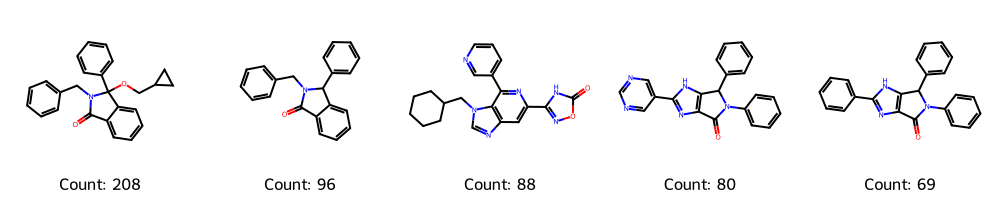


--- Top 5 Test Scaffolds (Should be different!) ---


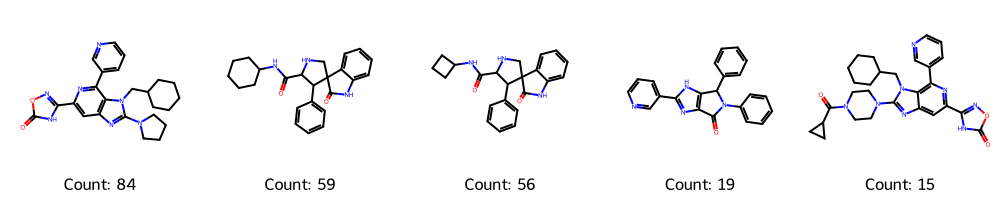


Computing t-SNE (this might take a moment)...


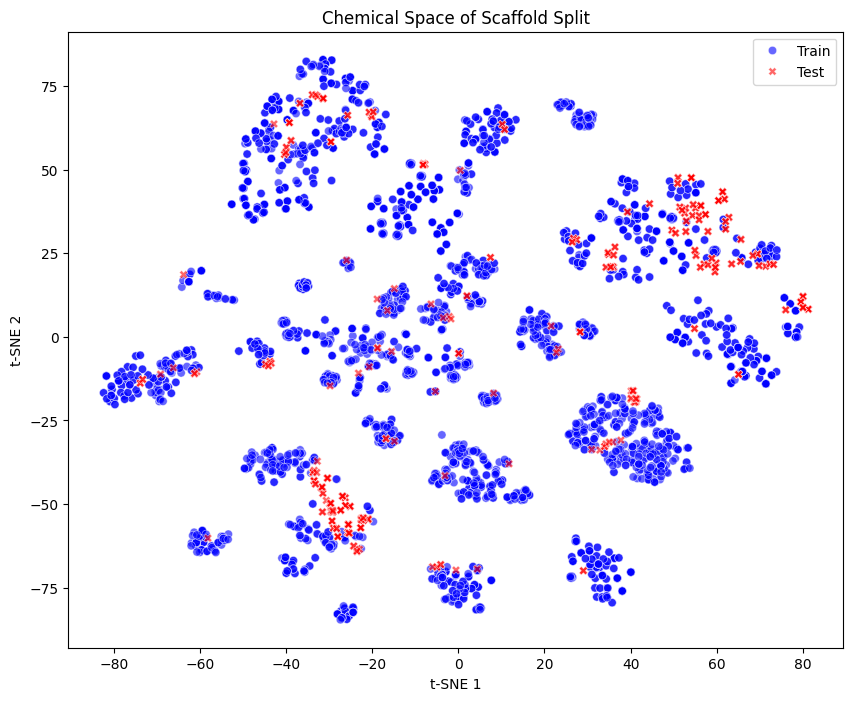

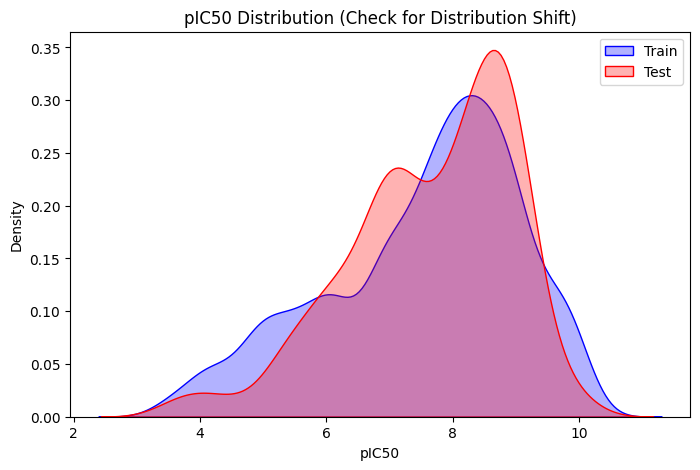

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

def visualize_scaffold_split(dataset, train_idx, val_idx, test_idx):
    """
    Generates a 3-part visualization of the scaffold split.
    1. Grid of Top Train vs. Top Test Scaffolds (Structural Distinctness)
    2. t-SNE plot of Chemical Space (Distribution)
    3. Distribution of pIC50s (Label Shift)
    """
    
    # --- Helper: Get Scaffold & Fingerprint ---
    def get_info(indices, label):
        scaffolds = []
        fps = []
        pics = []
        
        fp_gen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

        for idx in indices:
            smiles = dataset.df.iloc[idx]['SMILES']
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Get Scaffold
                scaff = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
                scaffolds.append(scaff)
                
                # Get Fingerprint (for t-SNE)
                fp = fp_gen.GetFingerprintAsNumPy(mol)
                fps.append(fp)
                
                # Get Label
                pics.append(dataset.df.iloc[idx]['pIC50'])
                
        return scaffolds, np.array(fps), np.array(pics)

    print("Analyzing Train Set...")
    train_scaffs, train_fps, train_y = get_info(train_idx, "Train")
    print("Analyzing Test Set...")
    test_scaffs, test_fps, test_y = get_info(test_idx, "Test")
    
    # --- PLOT 1: The "Face" of the Split (Top Scaffolds) ---
    from collections import Counter
    
    def draw_top_scaffolds(scaff_list, title, n=5):
        counts = Counter(scaff_list)
        top_scaffs = counts.most_common(n)
        
        mols = [Chem.MolFromSmiles(s) for s, c in top_scaffs]
        legends = [f"Count: {c}" for s, c in top_scaffs]
        
        img = Draw.MolsToGridImage(mols, molsPerRow=n, subImgSize=(200, 200), legends=legends)
        return img

    print(f"\n--- Top {5} Training Scaffolds ---")
    display(draw_top_scaffolds(train_scaffs, "Top Train Scaffolds"))
    
    print(f"\n--- Top {5} Test Scaffolds (Should be different!) ---")
    display(draw_top_scaffolds(test_scaffs, "Top Test Scaffolds"))

    # --- PLOT 2: Chemical Space t-SNE ---
    print("\nComputing t-SNE (this might take a moment)...")
    
    # Combine for t-SNE to ensure shared space
    X_all = np.vstack([train_fps, test_fps])
    labels = ["Train"] * len(train_fps) + ["Test"] * len(test_fps)
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_all)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=X_embedded[:, 0], 
        y=X_embedded[:, 1], 
        hue=labels, 
        style=labels,
        alpha=0.6,
        palette={"Train": "blue", "Test": "red"}
    )
    plt.title("Chemical Space of Scaffold Split")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

    # --- PLOT 3: Label Distribution ---
    plt.figure(figsize=(8, 5))
    sns.kdeplot(train_y, fill=True, label="Train", color="blue", alpha=0.3)
    sns.kdeplot(test_y, fill=True, label="Test", color="red", alpha=0.3)
    plt.title("pIC50 Distribution (Check for Distribution Shift)")
    plt.xlabel("pIC50")
    plt.legend()
    plt.show()

# Run it
visualize_scaffold_split(mol_data, train_idx, val_idx, test_idx)

In [19]:
len(scaffold_to_indices)

817

### Split Data into Train/Test/Val

In [ ]:
torch.manual_seed(42)  # Fixed seed for reproducibility
num_samples = len(mol_data)
indices = torch.randperm(num_samples).tolist()

train_size = int(0.8 * num_samples)
val_size = int(0.1 * num_samples)
test_size = num_samples - train_size - val_size

# Slice the Indices
train_indices = indices[:train_size]
val_indices = indices[train_size : train_size + val_size]
test_indices = indices[train_size + val_size :]

# Get the Protein Graph (from your ProteinFeaturizer)
protein_graph = protein_data.get_graph()

/Users/dantrainer/projects/cancer_research/src/mdm2_breaker/featurizers.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


## Modeling

### Graph Network v3 - GATv2Conv Layers. Add Bond Attributes. Add Atom Features.

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


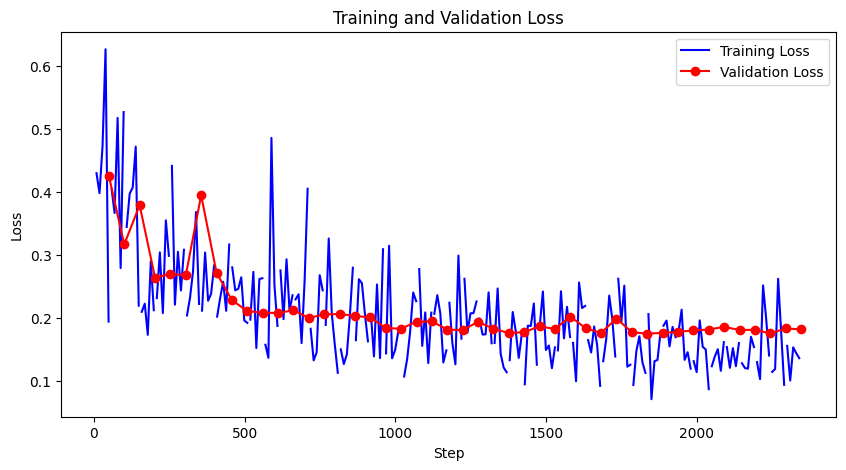

In [ ]:
model_v5, train_loader_v5, val_loader_v5, test_loader_v5 = train_model(
    model=GraphSiameseNetwork_v5(),
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_graph=protein_graph,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name="Model-v5-updated",
)
plot_loss("lightning_logs/version_5/metrics.csv")

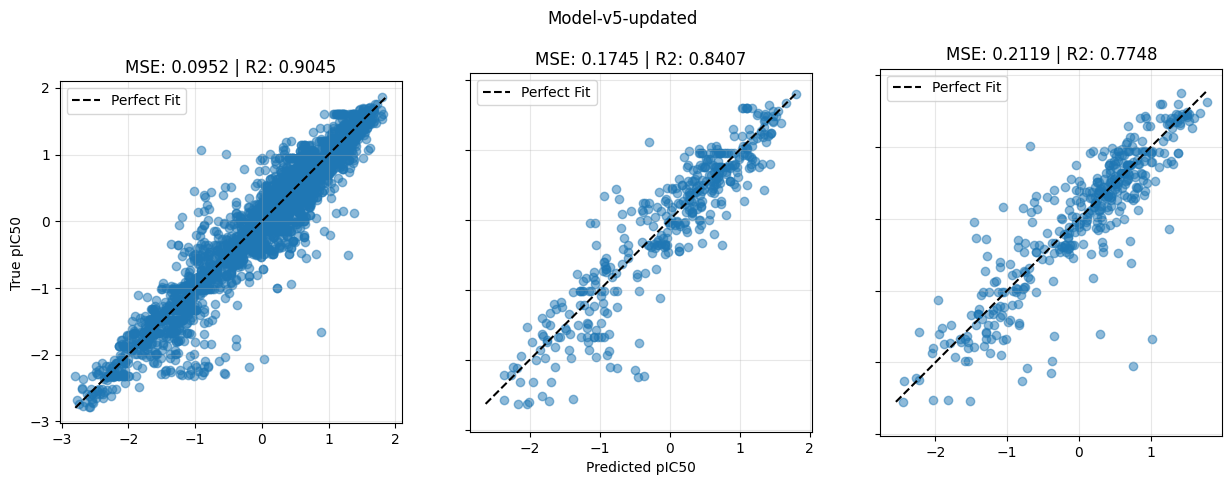

In [ ]:
model_v5 = load_model_from_checkpoint(
    GraphSiameseNetwork_v5, "checkpoints/Model-v5-updated.ckpt"
)
plot_predictions(
    model_v5,
    (train_loader_v5, val_loader_v5, test_loader_v5),
    protein_graph,
    "Model-v5-updated",
)

In [ ]:
ids

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

# 1. Create a molecule object from a SMILES string and add explicit hydrogens
# Adding hydrogens is crucial for realistic geometry
smiles = 'CCO' # Ethanol
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)

# 2. Generate multiple conformers using the ETKDG method
# numConfs: number of conformers to generate
# randomSeed: for reproducibility (optional)
# useExpTorsionAnglePrefs/useBasicKnowledge: part of ETKDG method (default to True)
num_confs = 10
ids = AllChem.EmbedMultipleConfs(mol, numConfs=num_confs, randomSeed=42, numThreads=0) # numThreads=0 uses all available threads

print(f"Generated {len(ids)} initial conformers.")

# 3. Optimize each conformer using a force field (e.g., UFF) and store energies
energies = []
for confId in ids:
    # UFFOptimizeMolecule is a wrapper for the UFF force field minimization
    # The energy is returned and minimization modifies the conformer coordinates in place
    energy = AllChem.UFFOptimizeMolecule(mol, confId=confId)
    energies.append((confId, energy))

# Sort conformers by energy (lowest energy first)
energies.sort(key=lambda x: x[1])
print(f"Optimized conformer energies (kcal/mol): {energies}")

# 4. Optional: Remove highly similar conformers after optimization using RMSD clustering
# This is often done after minimization to avoid redundancy
rms_thresh = 0.5 # RMSD threshold in Angstroms
# The AllChem.GetConformerRMSMatrix can calculate all-pairs RMSDs
rms_matrix = AllChem.GetConformerRMSMatrix(mol, prealigned=False)

# Simple clustering logic to keep a diverse set (more complex logic for real use cases)
# A common approach is a custom function or using a function that handles post-minimization clustering
# For a basic example of working with conformers and RMSD, see the RDKit blog

# Example of how to iterate through conformers
# for i in range(mol.GetNumConformers()):
#     conf = mol.GetConformer(i)
#     ...

# 5. Save the lowest energy conformer or all of them to an SDF file
writer = Chem.SDWriter('output_conformers.sdf')
if writer:
    for confId, energy in energies:
        mol.SetProp("Energy", str(energy))
        writer.write(mol, confId=confId)
    writer.close()
    print("Conformers written to output_conformers.sdf")
else:
    print("Could not open output_conformers.sdf for writing.")



Generated 10 initial conformers.
Optimized conformer energies (kcal/mol): [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0)]
Conformers written to output_conformers.sdf


In [ ]:
dataset_v5 = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
dataset_v5.df.head(3)

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152


3378


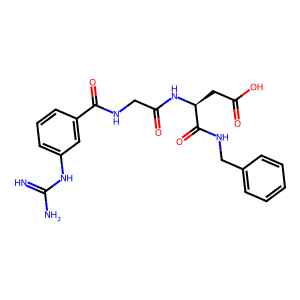

SMILES          NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C...
IC50                                                        >1000
Target                           E3 ubiquitin-protein ligase Mdm2
Organism                                             Homo sapiens
IC50_numeric                                               1000.0
pIC50                                                         6.0
pIC50_norm                                              -1.015267
Name: 3378, dtype: object

In [ ]:
target_pic = 6

idx = np.argmin(np.abs(dataset_v5.df['pIC50'] - target_pic))
print(idx)

mol = Chem.MolFromSmiles(dataset_v5.df.iloc[idx]['SMILES'])
img = Draw.MolToImage(
    mol,
)
display(img)

dataset_v5.df.iloc[idx]

In [ ]:
dataset_v5.df.iloc[idx]

SMILES          NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C...
IC50                                                        >1000
Target                           E3 ubiquitin-protein ligase Mdm2
Organism                                             Homo sapiens
IC50_numeric                                               1000.0
pIC50                                                         6.0
pIC50_norm                                              -1.015267
Name: 3378, dtype: object

In [ ]:
data = dataset_v5[idx]
data

Data(x=[39, 9], edge_index=[2, 82], edge_attr=[82, 4], y=[1], expert_features=[1, 2052])

In [ ]:
x_indices = data.x[:, :3].long()
x_floats = data.x[:, 3:].float()
x_embed = model_v5.atom_encoder(x_indices, x_floats).detach()

x_embed.shape

torch.Size([39, 128])

In [ ]:
from torch_geometric.nn import (
    global_add_pool,
    global_max_pool,
)

def calculate_design_gradients(model, data):

    # 1. PREPARE INPUTS
    # We need the protein data because the model expects it (Siamese)
    model.eval()
    model.zero_grad() # Clear previous gradients

    # 2. THE TRICK: Manually run the Atom Encoder first
    # This converts discrete integers -> continuous embeddings
    x_indices = data.x[:, :3].long()
    x_floats = data.x[:, 3:].float()

    # Run encoder, DETACH from graph, and RE-ENABLE gradients
    # This makes 'x_embed' the "Leaf Node" for the backward pass
    x_embed = model.atom_encoder(x_indices, x_floats).detach()
    x_embed.requires_grad = True 

    node_embeddings = model.molecule_encoder(x_embed, data.edge_index, data.edge_attr)

    # We need to tell PyTorch that all these 39 atoms belong to "Graph 0"
    batch = torch.zeros(node_embeddings.shape[0], dtype=torch.long, device=node_embeddings.device)

    # Pool them into a single Graph Vector
    v_sum = global_add_pool(node_embeddings, batch) # Shape: [1, 128]
    v_max = global_max_pool(node_embeddings, batch) # Shape: [1, 128]
    mol_vec = torch.cat([v_sum, v_max], dim=1)      # Shape: [1, 256]

    # B. Run Protein GNN
    with torch.no_grad():
        prot_vec = model.encode_protein(protein_graph) # Shape: [1, 256]

    # C. Prepare Expert Features
    expert_features = data.expert_features.squeeze(1) # Shape: [1, 2052]

    # DEBUG: Now they should all be 1 in the first dimension
    print(f"Shapes: Prot {prot_vec.shape}, Mol {mol_vec.shape}, Exp {expert_features.shape}")

    # D. Predictor
    combined = torch.cat([prot_vec, mol_vec, expert_features], dim=1)
    prediction = model.mlp(combined)

    print(f"Current Predicted pIC50: {prediction.item():.2f}")

    # 4. BACKWARD PASS
    loss = -prediction 
    loss.backward()

    # 5. EXTRACT GRADIENTS
    grads = x_embed.grad.norm(dim=1).cpu().numpy()
    print(grads.shape)
    print(grads)
    return grads

# # --- RUN IT ---
grads = calculate_design_gradients(model_v5, data = dataset_v5[idx])

Shapes: Prot torch.Size([1, 256]), Mol torch.Size([1, 256]), Exp torch.Size([1, 2052])
Current Predicted pIC50: -0.52
(39,)
[0.11916644 0.20607951 0.10395253 0.19799921 0.4117196  0.42521518
 0.4734667  0.41193154 0.45364738 0.37931192 0.32470757 0.16749415
 0.27021733 0.29909158 0.32705426 0.16278896 0.31607413 0.39490658
 0.31723326 0.3119213  0.19347513 0.17502959 0.3158358  0.16191843
 0.25084707 0.31866878 0.5281055  0.4590745  0.3751127  0.362892
 0.37878865 0.362892   0.3751127  0.4590745  0.3751127  0.362892
 0.37878865 0.362892   0.3751127 ]


SMILES: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1
Max Gradient: 0.5281


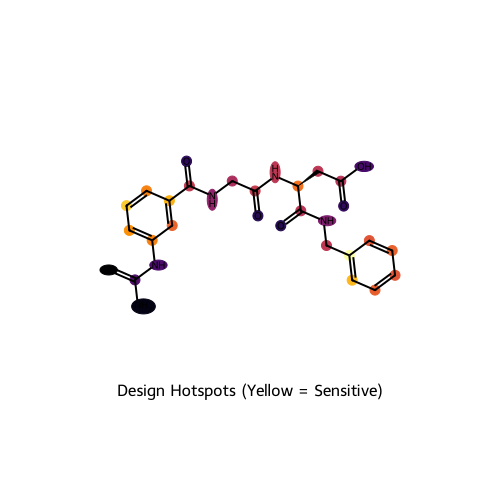

In [ ]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image

def visualize_gradient_hotspots(smiles, grads):
    # 1. Get Molecule
    mol = Chem.MolFromSmiles(smiles)
    # mol = Chem.AddHs(mol) # Match the GNN graph size (39 atoms)

    # 2. Safety Check: Index Alignment
    if mol.GetNumAtoms() != len(grads):
        print(f"Warning: Molecule has {mol.GetNumAtoms()} atoms but Gradients have {len(grads)}.")
        # Crop gradients to match if necessary to prevent crashing
        grads = grads[:mol.GetNumAtoms()]

    # 3. Normalize Gradients
    min_g, max_g = grads.min(), grads.max()
    range_g = max_g - min_g + 1e-9

    cmap = plt.get_cmap('inferno') # Yellow = Hot

    highlight_atoms = []
    highlight_colors = {}

    print(f"SMILES: {smiles}")
    print(f"Max Gradient: {max_g:.4f}")

    for aidx, g_score in enumerate(grads):
        norm_score = (g_score - min_g) / range_g
            
        highlight_atoms.append(aidx)
        
        # Get Color from Map
        rgba = cmap(norm_score)
        
        # --- THE FIX: Force conversion to Python floats ---
        # RDKit ignores numpy.float64, causing the "All Salmon" bug.
        color = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
        highlight_colors[aidx] = color
        
    # 4. High-Res Drawing with MolDraw2D
    d = rdMolDraw2D.MolDraw2DCairo(500, 500)
    d.drawOptions().useBWAtomPalette()
    d.drawOptions().padding = 0.2

    # Draw nicely
    d.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_colors,
        highlightBonds=[],
        legend=f"Design Hotspots (Yellow = Sensitive)"
    )
    d.FinishDrawing()
    
    return d

# # --- RUN IT ---
# # We use the 'grads' array you just calculated in the previous step
d = visualize_gradient_hotspots(smiles = dataset_v5.df.iloc[idx]['SMILES'], grads=grads)
display(Image(d.GetDrawingText()))

In [ ]:
def check_mutation_impact(model, dataset, mutant_smiles):
    # 1. One line to convert SMILES -> Tensor
    # This guarantees the features match training EXACTLY
    new_data = dataset.featurize_smiles(mutant_smiles)
    
    # 2. Score it
    model.eval()
    
    with torch.no_grad():
        # Pass to device if needed: new_data.to(model.device)
        pred = model(protein_graph, new_data).item()
        
    return pred

In [ ]:
from rdkit.Chem import AllChem

def test_benzylic_methylation_fixed(model, dataset, idx):
    # 1. Get Molecule
    smiles = dataset.df.iloc[idx]['SMILES']
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) # Explicit Hs are needed so we can find one to replace
    
    # 2. Identify Target (Benzylic Carbon)
    target_c_idx = -1
    target_h_idx = -1
    
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'C' and not atom.GetIsAromatic():
            # Check neighbors for an Aromatic Ring
            is_benzylic = False
            h_neighbor = -1
            
            for nbr in atom.GetNeighbors():
                if nbr.GetIsAromatic():
                    is_benzylic = True
                if nbr.GetSymbol() == 'H':
                    h_neighbor = nbr.GetIdx()
            
            # We need BOTH a ring connection AND a sacrificial Hydrogen
            if is_benzylic and h_neighbor != -1:
                target_c_idx = atom.GetIdx()
                target_h_idx = h_neighbor
                print(f"Found Benzylic Carbon: {target_c_idx}")
                print(f"Found Sacrificial Hydrogen: {target_h_idx}")
                break
    
    if target_h_idx == -1:
        print("Error: No suitable Benzylic Carbon with a Hydrogen found.")
        return

    # 3. Perform Mutation (Replace H with C)
    print(f"Mutating: Replacing Hydrogen {target_h_idx} with Methyl Group...")
    
    rw_mol = Chem.RWMol(mol)
    
    # Overwrite the Hydrogen atom with a Carbon atom
    # This keeps the bond to the parent carbon intact!
    # H-C  -->  C-C (Methyl)
    rw_mol.ReplaceAtom(target_h_idx, Chem.Atom(6))
    
    # 4. Clean Up
    try:
        # Sanitize calculates new valencies and adds implicit hydrogens to the new methyl
        Chem.SanitizeMol(rw_mol)
        new_smiles = Chem.MolToSmiles(rw_mol)
        print(f"\nOriginal: {smiles}")
        print(f"Mutant:   {new_smiles}")
        
        # 5. OPTIONAL: Visualize the change
        # display(Draw.MolToImage(rw_mol, size=(300,300), legend="Mutated Molecule"))
        
    except Exception as e:
        print(f"Mutation Failed: {e}")

    return new_smiles, smiles
# Run the Fixed Mutation
new_smiles, original_smiles = test_benzylic_methylation_fixed(model_v5, dataset_v5, idx=idx)

Found Benzylic Carbon: 25
Found Sacrificial Hydrogen: 50
Mutating: Replacing Hydrogen 50 with Methyl Group...

Original: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1
Mutant:   [H]N=C(N([H])[H])N([H])c1c([H])c([H])c([H])c(C(=O)N([H])C([H])([H])C(=O)N([H])[C@]([H])(C(=O)N([H])C([H])(C)c2c([H])c([H])c([H])c([H])c2[H])C([H])([H])C(=O)O[H])c1[H]


In [ ]:
check_mutation_impact(model_v5, dataset_v5, original_smiles)

-0.7737098932266235

In [ ]:
check_mutation_impact(model_v5, dataset_v5, new_smiles)

-0.7546812295913696

Shapes: Prot torch.Size([1, 256]), Mol torch.Size([1, 256]), Exp torch.Size([1, 2052])
Current Predicted pIC50: -0.75
(33,)
[0.15630451 0.29934928 0.17434143 0.20144066 0.23679824 0.20961575
 0.23309751 0.21565649 0.26927146 0.20566344 0.1121517  0.18771787
 0.21602279 0.24070615 0.12416963 0.24889784 0.4233918  0.34625143
 0.17686851 0.30396935 0.3663466  0.19574289 0.3921375  0.33723262
 0.35116723 0.36869738 0.35116723 0.33723262 0.30367413 0.27187708
 0.13893512 0.17554305 0.24981885]
SMILES: [H]N=C(N([H])[H])N([H])c1c([H])c([H])c([H])c(C(=O)N([H])C([H])([H])C(=O)N([H])[C@]([H])(C(=O)N([H])C([H])(C)c2c([H])c([H])c([H])c([H])c2[H])C([H])([H])C(=O)O[H])c1[H]
Max Gradient: 0.4234


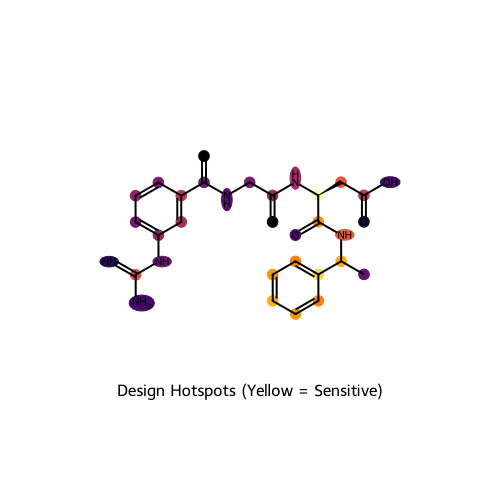

In [ ]:
new_data = dataset_v5.featurize_smiles(new_smiles)

grads = calculate_design_gradients(model_v5, data = new_data)
d = visualize_gradient_hotspots(smiles = new_smiles, grads=grads)
display(Image(d.GetDrawingText()))

<Axes: >

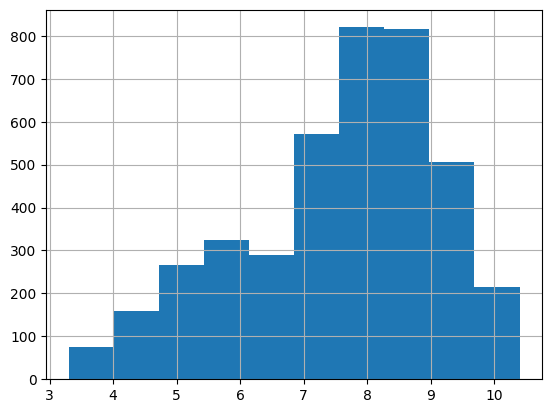

In [ ]:
dataset_v5.df["pIC50"].hist()

Option 1: Loading conformers from SDF file for 3D visualization...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Option 2: Display all conformers in a 2D grid...


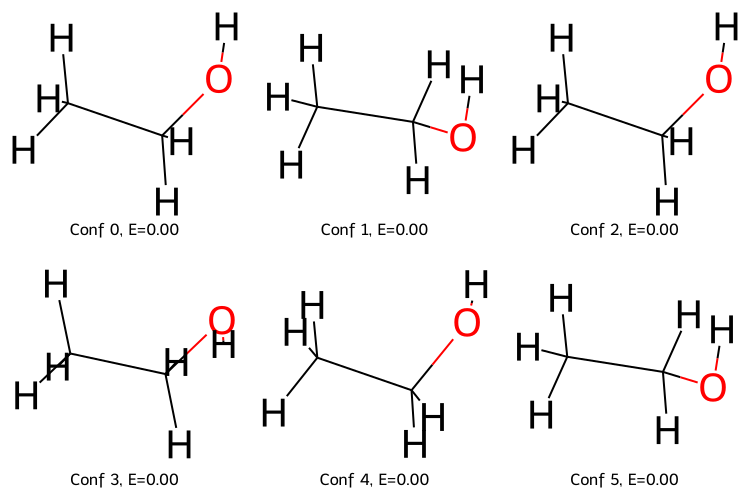


Option 3: Visualize lowest energy conformer in 3D...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# Visualize the generated conformers

# Option 1: Interactive 3D visualization using py3Dmol (from SDF file)
# This displays all conformers in a 3D viewer that you can rotate and zoom
print("Option 1: Loading conformers from SDF file for 3D visualization...")
with open('output_conformers.sdf', 'r') as f:
    sdf_content = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(sdf_content, 'sdf')
view.setStyle({'stick': {}})
view.zoomTo()
view.show()

print("\nOption 2: Display all conformers in a 2D grid...")
# Option 2: Show conformers in a 2D grid using RDKit
# Extract all conformers and display them side by side
mols_to_display = []
for confId, energy in energies[:6]:  # Show top 6 conformers
    # Create a copy of the molecule with just this conformer
    mol_copy = Chem.Mol(mol)
    mol_copy.RemoveAllConformers()
    mol_copy.AddConformer(mol.GetConformer(confId))
    mol_copy.SetProp("_Name", f"Conf {confId}, E={energy:.2f}")
    mols_to_display.append(mol_copy)

# Display in a grid (2 columns, 3 rows)
from IPython.display import Image, display
img = Draw.MolsToGridImage(mols_to_display, molsPerRow=3, subImgSize=(250, 250), 
                           legends=[m.GetProp("_Name") for m in mols_to_display])
display(img)

print("\nOption 3: Visualize lowest energy conformer in 3D...")
# Option 3: Show only the lowest energy conformer in 3D
lowest_conf_id, lowest_energy = energies[0]
mol_lowest = Chem.Mol(mol)
mol_lowest.RemoveAllConformers()
mol_lowest.AddConformer(mol.GetConformer(lowest_conf_id))

# Convert to SDF string
sdf_lowest = Chem.MolToMolBlock(mol_lowest)
view_lowest = py3Dmol.view(width=600, height=400)
view_lowest.addModel(sdf_lowest, 'mol')
view_lowest.setStyle({'stick': {}, 'sphere': {'radius': 0.3}})
view_lowest.setBackgroundColor('0xeeeeee')
view_lowest.zoomTo()
view_lowest.show()


<Axes: >

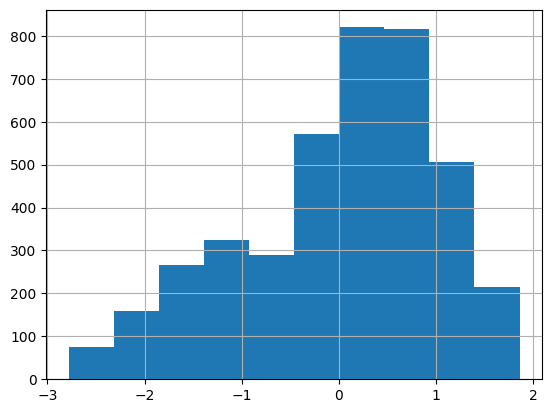

In [ ]:
dataset_v5.df["pIC50_norm"].hist()

In [ ]:
import torch
import torch.nn.functional as F
from rdkit import Chem

def build_atom_palette(model):
    """
    Creates 'Ideal' embeddings for common atom types so we can compare 
    our 'dreamed' atoms against them.
    """
    palette = {}
    
    # We define a few standard 'Archetypes' based on what your model likely learned.
    # We create tiny dummy molecules to generate these valid embeddings.
    archetypes = [
        ('C_aliphatic', 'C'),      # Methane-like
        ('C_aromatic', 'c1ccccc1'),# Benzene-like
        ('N_amine', 'N'),          # Ammonia-like
        ('N_aromatic', 'n1ccccc1'),# Pyridine-like
        ('O_ether', 'COC'),        # Ether-like
        ('O_carbonyl', 'C=O'),     # Ketone-like
        ('F', 'CF'),               # Fluorine
        ('Cl', 'CCl'),             # Chlorine
    ]
    
    print("Building Reference Palette...")
    model.eval()
    
    for name, smiles in archetypes:
        mol = Chem.MolFromSmiles(smiles)
        mol = Chem.AddHs(mol)
        
        # We need to extract the feature vector for the specific atom of interest
        # Usually the first atom in these simple strings is the one we want (Index 0)
        # Exception: 'n1ccccc1' -> The 'n' is usually index 0.
        
        # 1. Featurize (Use your class logic manually or a helper)
        # We need the raw inputs for the AtomEncoder (Indices + Floats)
        # Let's assume you have a helper `get_raw_features_for_atom(atom)` 
        # based on your Featurizer logic.
        
        # Quick Hack: Use your featurizer on the whole mol, take row 0
        # (Assuming your dataset/featurizer is accessible)
        data = dataset_v5.featurize_smiles(smiles) 
        
        # 2. Pass through AtomEncoder
        x_indices = data.x[:, :3].long()
        x_floats = data.x[:, 3:].float()
        
        with torch.no_grad():
            embeddings = model.atom_encoder(x_indices, x_floats)
            
        # Store the vector for the first atom (the target)
        palette[name] = embeddings[0].detach() # Shape: [128]

    return palette

palette = build_atom_palette(model_v5)
palette

Building Reference Palette...


{'C_aliphatic': tensor([-0.8158, -0.2904,  1.6880,  0.7132,  0.1796, -2.3216,  0.1208, -0.3404,
         -0.9963, -0.1704, -1.0356,  0.9743, -0.7458,  0.1179,  1.0365,  0.6440,
          1.3637, -0.9279,  0.2440, -0.6742,  0.7434, -1.5947, -1.1947,  0.7879,
          0.2601, -1.1143,  0.3949,  0.1644, -0.3948,  0.4756, -0.1296,  0.3320,
         -1.8392,  0.7280,  0.6695, -0.2012,  0.5530, -0.3184,  0.3372, -0.7420,
         -0.5246,  0.8463, -0.7568,  0.1994, -0.1692, -0.5364,  1.9232,  1.6045,
         -1.7905,  0.9817, -1.4249,  0.1685, -0.3497, -1.4091, -0.8677, -0.3839,
          1.6510, -0.7566, -0.3161, -0.6563, -0.0899, -0.6638, -0.2174,  1.6250,
          0.3870,  0.3642, -0.3058,  0.1139,  0.6155, -0.2362, -0.1378,  0.3884,
          0.2999, -0.2238,  0.5826, -0.1817, -0.1166, -0.3335,  0.2523, -0.4077,
         -0.0560,  0.1743, -0.3457, -0.1876, -0.2236,  0.3725,  0.2911,  0.2971,
         -0.1680, -0.2203,  0.0806, -0.1012, -0.0588,  0.2597, -0.1813,  0.3425,
         -0.3

In [ ]:
def dream_optimize_molecule(model, dataset, smiles, steps=100, lr=0.1):
    # 1. Setup Data
    data = dataset.featurize_smiles(smiles)
    
    # 2. Get Initial Embeddings (The "Real" Molecule)
    model.eval()
    x_indices = data.x[:, :3].long()
    x_floats = data.x[:, 3:].float()
    
    # Generate the starting point
    x_init = model.atom_encoder(x_indices, x_floats).detach()
    
    # 3. Create the "Dream" Variable
    # We clone it and enable gradients. This is what we will "mutate".
    x_dream = x_init.clone().detach().requires_grad_(True)
    
    # 4. The Optimizer (Adam works best for "Dreaming")
    optimizer = torch.optim.Adam([x_dream], lr=lr)
    
    print(f"--- Dreaming Start: {smiles[:30]}... ---")
    
    # 5. The Loop
    for i in range(steps):
        optimizer.zero_grad()
        
        # A. Inject Dream into Model
        # We use your 'forward_from_embeddings' or manually call the inner layers
        mol_vec = model.encode_molecule_inner(
            x_dream, 
            data.edge_index, 
            data.edge_attr, 
            data.batch
        )
        
        # B. Protein & Expert Features (Fixed)
        with torch.no_grad():
            prot_vec = model.encode_protein(protein_graph)
            if prot_vec.shape[0] != mol_vec.shape[0]: 
                prot_vec = prot_vec.expand(mol_vec.shape[0], -1)
            expert = data.expert_features.squeeze(1)
            
        # C. Predict
        combined = torch.cat([prot_vec, mol_vec, expert], dim=1)
        prediction = model.mlp(combined)
        
        # D. Loss (Maximize pIC50 -> Minimize Negative pIC50)
        loss = -prediction
        loss.backward()
        
        # E. Update
        optimizer.step()
        
        if i % 20 == 0:
            print(f"Step {i}: Predicted pIC50 = {prediction.item():.2f}")
            
    print(f"Final Dream Score: {prediction.item():.2f}")
    return x_init, x_dream



In [ ]:
def analyze_dream_drift(model, dataset, smiles, palette, steps=50):
    # Run the Dream
    x_init, x_dream = dream_optimize_molecule(model, dataset, smiles, steps=steps)
    
    # Get Molecule for indexing
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    
    print("\n--- ANALYSIS: Where did the atoms drift? ---")
    
    drift_report = []
    
    for i in range(x_dream.shape[0]):
        atom = mol.GetAtomWithIdx(i)
        symbol = atom.GetSymbol()
        is_aromatic = atom.GetIsAromatic()
        
        # Skip Hydrogens (Usually less interesting, though you can check them too)
        if symbol == 'H': continue
            
        # 1. Get Vectors
        start_vec = x_init[i]
        end_vec = x_dream[i]
        
        # 2. Did it move? (Euclidean Distance)
        drift_magnitude = torch.norm(end_vec - start_vec).item()
        
        if drift_magnitude < 0.5: continue # Ignore atoms that stayed put
            
        # 3. Compare to Palette (Cosine Similarity)
        # We want to find which archetype the dream vector is now CLOSEST to.
        best_match = "None"
        best_sim = -1.0
        
        for name, ref_vec in palette.items():
            # Cosine Similarity: (A . B) / (|A| * |B|)
            sim = F.cosine_similarity(end_vec.unsqueeze(0), ref_vec.unsqueeze(0)).item()
            
            if sim > best_sim:
                best_sim = sim
                best_match = name
        
        # 4. Report if it changed identity
        # e.g., if it started as Carbon but drifted closer to Nitrogen
        start_type = f"{symbol}_{'aromatic' if is_aromatic else 'aliphatic'}"
        
        print(f"Atom {i} ({start_type}): Drift={drift_magnitude:.2f} -> Wants to be {best_match} (Sim: {best_sim:.2f})")
        
        drift_report.append({
            'idx': i,
            'original': start_type,
            'dream': best_match,
            'drift': drift_magnitude
        })
        
    return drift_report

# --- EXECUTE LEVEL 3 ---
report = analyze_dream_drift(model_v5, dataset_v5, dataset_v5.df.iloc[3378]['SMILES'], palette)

--- Dreaming Start: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N... ---
Step 0: Predicted pIC50 = -0.77
Step 20: Predicted pIC50 = 12.51
Step 40: Predicted pIC50 = 39.04
Final Dream Score: 54.69

--- ANALYSIS: Where did the atoms drift? ---
Atom 0 (N_aliphatic): Drift=24.49 -> Wants to be N_aromatic (Sim: 0.34)
Atom 1 (C_aliphatic): Drift=24.55 -> Wants to be O_carbonyl (Sim: 0.25)
Atom 2 (N_aliphatic): Drift=24.49 -> Wants to be N_aromatic (Sim: 0.33)
Atom 3 (N_aliphatic): Drift=22.10 -> Wants to be N_aromatic (Sim: 0.38)
Atom 4 (C_aromatic): Drift=25.01 -> Wants to be C_aromatic (Sim: 0.47)
Atom 5 (C_aromatic): Drift=25.93 -> Wants to be C_aromatic (Sim: 0.45)
Atom 6 (C_aromatic): Drift=25.55 -> Wants to be C_aromatic (Sim: 0.47)
Atom 7 (C_aromatic): Drift=26.08 -> Wants to be C_aromatic (Sim: 0.44)
Atom 8 (C_aromatic): Drift=25.74 -> Wants to be C_aromatic (Sim: 0.46)
Atom 9 (C_aromatic): Drift=24.93 -> Wants to be C_aromatic (Sim: 0.43)
Atom 10 (C_aliphatic): Drift=22.72 -> Wants to be O_carbony

In [ ]:
def test_carbonyl_mutation(model, dataset, idx, target_atom_idx=10):
    # 1. Setup
    smiles = dataset.df.iloc[idx]['SMILES']
    print(f"Original SMILES: {smiles}")
    
    # Check baseline score
    # baseline_score = dataset.check_mutation_impact(model, smiles) # Using your new helper
    baseline_score = check_mutation_impact(model, dataset, smiles)
    print(f"Baseline Score: {baseline_score:.4f}")

    # 2. Prepare Molecule
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) # Crucial to see/remove the Hs
    rw_mol = Chem.RWMol(mol)
    
    # 3. The Operation: Make it a Ketone (C=O)
    print(f"\n--- Mutating Atom {target_atom_idx} to Carbonyl (C=O) ---")
    
    # A. Check if it's a Carbon
    atom = rw_mol.GetAtomWithIdx(target_atom_idx)
    if atom.GetSymbol() != 'C':
        print(f"Error: Target atom is {atom.GetSymbol()}, not Carbon!")
        return

    # B. Remove Hydrogens attached to this Carbon
    # We must collect them first, then remove, to avoid index shifting issues
    h_neighbors = []
    for nbr in atom.GetNeighbors():
        if nbr.GetSymbol() == 'H':
            h_neighbors.append(nbr.GetIdx())
            
    # Delete the H atoms (Reverse order to be safe with indices, 
    # though RWMol handles ID drifting carefully, direct deletion is safest descending)
    h_neighbors.sort(reverse=True)
    for h_idx in h_neighbors:
        rw_mol.RemoveAtom(h_idx)
        
    # C. Add the Oxygen
    new_o_idx = rw_mol.AddAtom(Chem.Atom(8)) # Oxygen
    
    # D. Add Double Bond (Target C = New O)
    # Note: We need to be careful about the index of Target C. 
    # If we deleted atoms *before* it, its index shifted.
    # But since we only deleted Hs (which usually come *after* heavy atoms in AddHs),
    # the heavy atom indices *should* be stable. 
    # SAFETY CHECK: RDKit doesn't guarantee this. 
    # BETTER WAY: Use the original object reference if possible, or track the shift.
    # For now, let's assume standard RDKit behavior (Hs at end).
    
    rw_mol.AddBond(target_atom_idx, new_o_idx, Chem.BondType.DOUBLE)
    
    # 4. Sanitize & Score
    try:
        Chem.SanitizeMol(rw_mol)
        new_smiles = Chem.MolToSmiles(rw_mol)
        print(f"Mutant SMILES: {new_smiles}")
        
        # 5. Score
        # new_score = dataset.check_mutation_impact(model, new_smiles)
        new_score = check_mutation_impact(model, dataset, new_smiles)
        print(f"New Score:     {new_score:.4f}")
        
        delta = new_score - baseline_score
        if delta > 0:
            print(f"RESULT: SUCCESS (+{delta:.4f}) - The Dream was real!")
        else:
            print(f"RESULT: FAILURE ({delta:.4f}) - The model was hallucinating.")

    
        return new_smiles, new_score
            
    except Exception as e:
        print(f"Chemical Error (Valence/Sanitization): {e}")
        return None, None

# Run it
new_smiles, new_score = test_carbonyl_mutation(model_v5, dataset_v5, idx=3378, target_atom_idx=10)

Original SMILES: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1
Baseline Score: -0.7737

--- Mutating Atom 10 to Carbonyl (C=O) ---
Chemical Error (Valence/Sanitization): Explicit valence for atom # 10 C, 6, is greater than permitted


[14:43:31] Explicit valence for atom # 10 C, 6, is greater than permitted


In [ ]:
from rdkit import Chem

def test_carbonyl_mutation_robust(model, dataset, idx, target_atom_idx=10):
    # 1. Setup
    smiles = dataset.df.iloc[idx]['SMILES']
    print(f"Original: {smiles}")
    
    # 2. Prepare Molecule with Explicit Hs
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) 
    rw_mol = Chem.RWMol(mol)
    
    atom = rw_mol.GetAtomWithIdx(target_atom_idx)
    
    # 3. Safety Check: Geometry
    # A Ketone (C=O) requires the carbon to have exactly 2 other neighbors.
    # If it has 3 (branching), you can't make it a C=O without breaking the backbone.
    heavy_neighbors = [n for n in atom.GetNeighbors() if n.GetSymbol() != 'H']
    h_neighbors = [n for n in atom.GetNeighbors() if n.GetSymbol() == 'H']
    
    print(f"\n--- Analysis of Atom {target_atom_idx} ({atom.GetSymbol()}) ---")
    print(f"Heavy Neighbors: {len(heavy_neighbors)} | Hydrogens: {len(h_neighbors)}")
    
    if len(heavy_neighbors) > 2:
        print("ABORT: This carbon is a branch point (3+ connections). Cannot turn into C=O without breaking chains.")
        return
    if len(h_neighbors) == 0:
        print("ABORT: No Hydrogens to sacrifice. Is this already a double bond?")
        return

    # 4. The Surgery
    print("Performing Robust Oxidation...")
    
    # Step A: Pick a Hydrogen to transform into Oxygen
    h_to_keep_idx = h_neighbors[0].GetIdx()
    
    # Step B: Pick the other Hydrogens to DELETE
    # We collect indices first to avoid "shifting index" bugs during deletion
    hs_to_delete = [h.GetIdx() for h in h_neighbors[1:]]
    
    # Step C: Delete the extra Hydrogens
    # Sort reverse to keep indices valid during sequential deletion
    hs_to_delete.sort(reverse=True)
    for h_idx in hs_to_delete:
        rw_mol.RemoveAtom(h_idx)
        
    # Step D: Transmute the remaining H -> O
    # We get the atom again because the graph changed slightly
    target_h = rw_mol.GetAtomWithIdx(h_to_keep_idx)
    target_h.SetAtomicNum(8) # Turn H into Oxygen
    
    # Step E: Upgrade the Bond (C-O -> C=O)
    # The bond exists (it was the C-H bond), we just change its type
    rw_mol.GetBondBetweenAtoms(target_atom_idx, h_to_keep_idx).SetBondType(Chem.BondType.DOUBLE)
    
    # 5. Sanitize & Score
    try:
        Chem.SanitizeMol(rw_mol)
        new_smiles = Chem.MolToSmiles(rw_mol)
        print(f"Mutant:   {new_smiles}")
        
        # Score it
        new_score = dataset.check_mutation_impact(model, new_smiles)
        
        # Compare
        baseline = dataset.check_mutation_impact(model, smiles)
        print(f"Baseline: {baseline:.4f} -> New: {new_score:.4f}")
        print(f"Delta:    {new_score - baseline:.4f}")
        
    except Exception as e:
        print(f"Chemical Error: {e}")

# Run the robust version
test_carbonyl_mutation_robust(model_v5, dataset_v5, idx=3378, target_atom_idx=10)

Original: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1

--- Analysis of Atom 10 (C) ---
Heavy Neighbors: 3 | Hydrogens: 0
ABORT: This carbon is a branch point (3+ connections). Cannot turn into C=O without breaking chains.


In [ ]:
import copy
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem import AllChem

class SarcomaDesigner:
    def __init__(self, model, dataset, protein_graph):
        """
        Args:
            model: The trained GraphSiameseNetwork_v5
            dataset: The SmallMoleculeFeaturizer_v5 (for processing SMILES)
            protein_graph: The static Data object for MDM2
        """
        self.model = model
        self.dataset = dataset
        self.protein_graph = protein_graph
        self.model.eval()
        
    def predict(self, smiles):
        """Featurizes a SMILES string and returns the model's pIC50 prediction."""
        # Featurize using your V5 logic (Calculates GNN feats + Morgan + Descriptors)
        data = self.dataset.featurize_smiles(smiles)
        
        if data is None: 
            return -100.0 # Invalid molecule
            
        with torch.no_grad():
            # Send to same device as model
            # Note: We assume model is on CPU for inference to avoid VRAM juggling, 
            # but you can add .to('cuda') here if needed.
            pred = self.model(self.protein_graph, data)
            
        return pred.item()

    def scan_methylations(self, mol):
        """
        Strategy: Hydrophobic packing.
        Finds every Carbon with a Hydrogen and replaces one H with a Methyl group (-CH3).
        """
        mutations = []
        original_smiles = Chem.MolToSmiles(mol)
        
        # We iterate over atoms
        for atom in mol.GetAtoms():
            if atom.GetSymbol() == 'C' and atom.GetTotalNumHs() > 0:
                idx = atom.GetIdx()
                
                # Perform Surgery
                rw_mol = Chem.RWMol(mol)
                
                # Get a neighbor H to replace
                h_neighbor = -1
                for nbr in rw_mol.GetAtomWithIdx(idx).GetNeighbors():
                    if nbr.GetSymbol() == 'H':
                        h_neighbor = nbr.GetIdx()
                        break
                
                if h_neighbor != -1:
                    # RDKit Trick: Instead of deleting H and adding C, 
                    # we just Transmute the H into a C!
                    # RDKit will auto-adjust the implicit Hydrogens on the new Methyl 
                    # after Sanitize.
                    rw_mol.GetAtomWithIdx(h_neighbor).SetAtomicNum(6) 
                    
                    try:
                        Chem.SanitizeMol(rw_mol)
                        new_smiles = Chem.MolToSmiles(rw_mol)
                        if new_smiles != original_smiles:
                            mutations.append({
                                'type': 'Methyl_Scan',
                                'atom_idx': idx,
                                'smiles': new_smiles,
                                'desc': f"Added Methyl at C{idx}"
                            })
                    except:
                        pass # Invalid chemistry
        return mutations

    def scan_fluorination(self, mol):
        """
        Strategy: Metabolic Stability & Electronic effects.
        Finds Aromatic Carbons with Hydrogens and swaps H -> F.
        """
        mutations = []
        
        for atom in mol.GetAtoms():
            # Target: Aromatic Carbon (c)
            if atom.GetSymbol() == 'C' and atom.GetIsAromatic() and atom.GetTotalNumHs() > 0:
                idx = atom.GetIdx()
                rw_mol = Chem.RWMol(mol)
                
                # Find the H neighbor
                h_neighbor = -1
                for nbr in rw_mol.GetAtomWithIdx(idx).GetNeighbors():
                    if nbr.GetSymbol() == 'H':
                        h_neighbor = nbr.GetIdx()
                        break
                
                if h_neighbor != -1:
                    # Transmute H -> F (Atomic Num 9)
                    rw_mol.GetAtomWithIdx(h_neighbor).SetAtomicNum(9)
                    
                    try:
                        Chem.SanitizeMol(rw_mol)
                        mutations.append({
                            'type': 'Fluoro_Scan',
                            'atom_idx': idx,
                            'smiles': Chem.MolToSmiles(rw_mol),
                            'desc': f"H -> F at Aromatic C{idx}"
                        })
                    except:
                        pass
        return mutations

    def scan_carbonyls(self, mol):
        """
        Strategy: Hydrogen Bond Acceptor addition.
        Finds aliphatic CH2 groups and converts them to C=O (Ketone/Amide).
        """
        mutations = []
        
        for atom in mol.GetAtoms():
            # Target: Aliphatic Carbon with >= 2 Hydrogens
            if atom.GetSymbol() == 'C' and not atom.GetIsAromatic() and atom.GetTotalNumHs() >= 2:
                idx = atom.GetIdx()
                
                # Check connectivity (don't break 4-way junctions)
                heavy_neighbors = [n for n in atom.GetNeighbors() if n.GetSymbol() != 'H']
                if len(heavy_neighbors) > 2: continue 

                rw_mol = Chem.RWMol(mol)
                
                # We need to remove 2 Hydrogens and add 1 Oxygen (Double Bond)
                # Or: Transmute 1 H -> O, Delete other H, Set Double Bond.
                
                h_neighbors = [n for n in rw_mol.GetAtomWithIdx(idx).GetNeighbors() if n.GetSymbol() == 'H']
                if len(h_neighbors) < 2: continue
                
                h1_idx = h_neighbors[0].GetIdx()
                h2_idx = h_neighbors[1].GetIdx()
                
                # 1. Remove one H
                rw_mol.RemoveAtom(h2_idx)
                
                # 2. Transmute other H to O
                # Note: Because we removed an atom, indices might shift if h1_idx > h2_idx
                # But RWMol handles ID tracking fairly well. To be safe, re-fetch.
                # Simplified approach: Just ReplaceAtom logic usually safer.
                
                # Let's try the Robust Oxidation logic from your notebook:
                # Transmute H1 -> O
                target_O = rw_mol.GetAtomWithIdx(h1_idx)
                target_O.SetAtomicNum(8) 
                
                # Change Bond Type (C-O -> C=O)
                bond = rw_mol.GetBondBetweenAtoms(idx, h1_idx)
                bond.SetBondType(Chem.rdchem.BondType.DOUBLE)
                
                try:
                    Chem.SanitizeMol(rw_mol)
                    mutations.append({
                        'type': 'Oxidation',
                        'atom_idx': idx,
                        'smiles': Chem.MolToSmiles(rw_mol),
                        'desc': f"Oxidized C{idx} to C=O"
                    })
                except:
                    pass
                    
        return mutations

    def generate_suggestions(self, smiles):
        """
        Main entry point. Runs all scans and ranks them.
        """
        mol = Chem.MolFromSmiles(smiles)
        mol = Chem.AddHs(mol) # Crucial for finding Hs to replace
        
        baseline_score = self.predict(smiles)
        print(f"Baseline pIC50: {baseline_score:.4f}")
        
        all_mutations = []
        all_mutations.extend(self.scan_methylations(mol))
        all_mutations.extend(self.scan_fluorination(mol))
        all_mutations.extend(self.scan_carbonyls(mol))
        
        print(f"Generated {len(all_mutations)} candidates. Scoring...")
        
        results = []
        for m in all_mutations:
            score = self.predict(m['smiles'])
            delta = score - baseline_score
            
            results.append({
                'Mutation Type': m['type'],
                'Location': m['atom_idx'],
                'Description': m['desc'],
                'Predicted pIC50': score,
                'Delta': delta,
                'SMILES': m['smiles']
            })
            
        df = pd.DataFrame(results)
        if not df.empty:
            df = df.sort_values(by='Predicted pIC50', ascending=False).reset_index(drop=True)
            
        return df, baseline_score

In [ ]:
# 1. Instantiate the Engine
designer = SarcomaDesigner(
    model=model_v5, 
    dataset=dataset_v5, 
    protein_graph=protein_graph
)

# 2. Pick a starting molecule (e.g., the one from your previous analysis)
# idx = 3378 (from your notebook)
start_smiles = dataset_v5.df.iloc[3378]['SMILES']

# 3. Run the Design Loop
design_df, baseline = designer.generate_suggestions(start_smiles)

# 4. View Top 5 Improvements
print(f"Base Score: {baseline:.4f}")
display(design_df.head(5))

# 5. Visualize the winner
from rdkit.Chem import Draw

if not design_df.empty:
    best_smiles = design_df.iloc[0]['SMILES']
    best_delta = design_df.iloc[0]['Delta']
    
    if best_delta > 0:
        print(f"Top Candidate: +{best_delta:.4f} improvement!")
        img = Draw.MolsToGridImage(
            [Chem.MolFromSmiles(start_smiles), Chem.MolFromSmiles(best_smiles)],
            molsPerRow=2,
            subImgSize=(300, 300),
            legends=["Original", f"Mutant (+{best_delta:.2f})"]
        )
        display(img)
    else:
        print("No mutations improved the score. The model thinks this molecule is a local maximum for these rules.")

Baseline pIC50: -0.7737
Generated 0 candidates. Scoring...
Base Score: -0.7737


""
